In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import *

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam

In [5]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


In [6]:
# MNIST data
train_set = MNIST(root='./data', train=True, transform=ToTensor(), download=True)
test_set = MNIST(root='./data', train=False, transform=ToTensor(), download=True)
# data loader
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

### 실습1. Noised image -> clean image

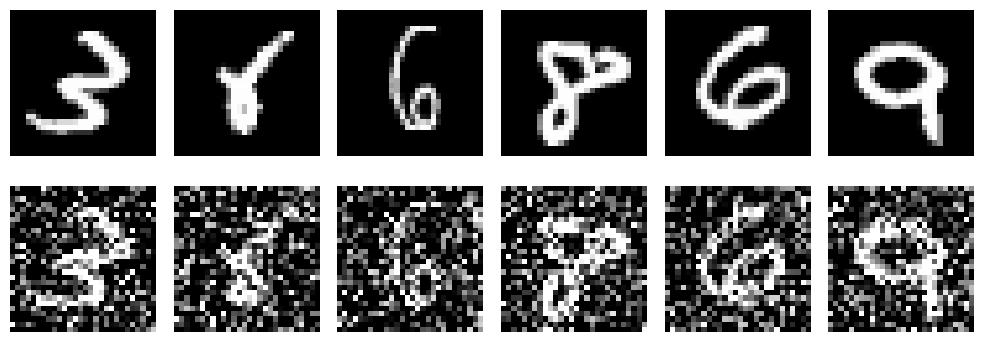

In [7]:
# 데이터에 노이즈 추가
def add_noise(imgs, noise_factor=0.5):
    noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
    noisy_imgs = torch.clip(noisy_imgs, 0., 1.)
    return noisy_imgs

x, _ = next(iter(train_loader))
noisy_x = add_noise(x)
plt.figure(figsize=(10, 4))
for i in range(6):
    # 원본 이미지
    plt.subplot(2, 6, i + 1)
    plt.imshow(x[i][0], cmap='gray')
    plt.axis('off')
    # 노이즈 이미지
    plt.subplot(2, 6, i + 7)
    plt.imshow(noisy_x[i][0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# auto encoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder: 784 → 128 → 64 → 32
        self.encoder = nn.Sequential(
        nn.Linear(28*28, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 32), nn.ReLU() )
        # Decoder: 32 → 64 → 128 → 784
        self.decoder = nn.Sequential(
        nn.Linear(32, 64), nn.ReLU(),
        nn.Linear(64, 128), nn.ReLU(),
        nn.Linear(128, 28*28),
        nn.Sigmoid() ) # 픽셀 범위를 [0,1]로 맞추기 위해 시그모이드 함수 사용
    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(x.size(0), 1, 28, 28)

In [9]:
model = Autoencoder().to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

# training
epochs = 20
for t in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        noisy_imgs = add_noise(imgs).to(device)
        imgs = imgs.to(device)
        outputs = model(noisy_imgs)
        loss = loss_fn(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    tr_loss = running_loss / len(train_loader)
    print(f"Epoch {t+1}, train loss: {tr_loss:.6f}")

Epoch 1, train loss: 0.068466
Epoch 2, train loss: 0.043742
Epoch 3, train loss: 0.035047
Epoch 4, train loss: 0.031161
Epoch 5, train loss: 0.029302
Epoch 6, train loss: 0.028021
Epoch 7, train loss: 0.026960
Epoch 8, train loss: 0.025956
Epoch 9, train loss: 0.024954
Epoch 10, train loss: 0.024162
Epoch 11, train loss: 0.023570
Epoch 12, train loss: 0.023053
Epoch 13, train loss: 0.022629
Epoch 14, train loss: 0.022205
Epoch 15, train loss: 0.021797
Epoch 16, train loss: 0.021433
Epoch 17, train loss: 0.021094
Epoch 18, train loss: 0.020731
Epoch 19, train loss: 0.020397
Epoch 20, train loss: 0.020132


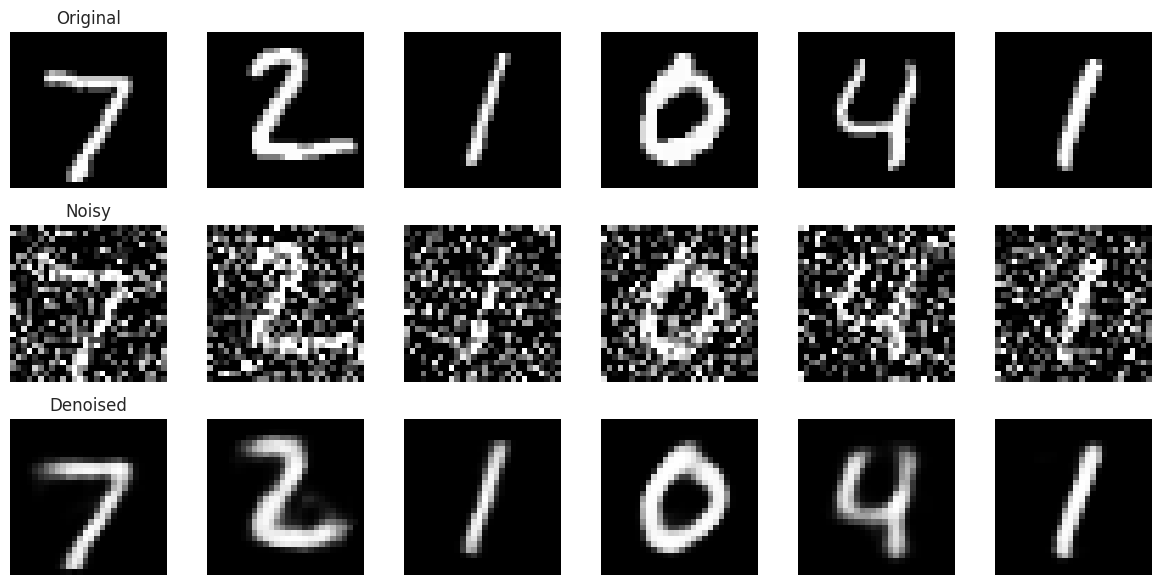

In [10]:
# pred and eval
model.eval()
imgs, _ = next(iter(test_loader))
noisy_imgs = add_noise(imgs).to(device)
with torch.no_grad():
    outputs = model(noisy_imgs)

imgs = imgs[:6].cpu()
noisy_imgs = noisy_imgs[:6].cpu()
outputs = outputs[:6].cpu()
plt.figure(figsize=(12, 6))
for i in range(6):
    # 원본
    plt.subplot(3, 6, i + 1)
    plt.imshow(imgs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Original")
    # 노이즈
    plt.subplot(3, 6, i + 7)
    plt.imshow(noisy_imgs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Noisy")
    # 복원
    plt.subplot(3, 6, i + 13)
    plt.imshow(outputs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Denoised")

plt.tight_layout()
plt.show()

### 실습2. 차원축소

In [11]:
# model
class Autoencoder2D(nn.Module):
    def __init__(self):
        super(Autoencoder2D, self).__init__()
        self.encoder = nn.Sequential(
                        nn.Linear(784, 128), nn.ReLU(),
                        nn.Linear(128, 64), nn.ReLU(),
                        nn.Linear(64, 2))
        self.decoder = nn.Sequential(
                        nn.Linear(2, 64), nn.ReLU(),
                        nn.Linear(64, 128), nn.ReLU(),
                        nn.Linear(128, 784),
                        nn.Sigmoid())
    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(x.size(0), 1, 28, 28)
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

In [12]:
model = Autoencoder2D().to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

# training
epochs = 20
for t in range(epochs):
    model.train() # 학습 모드
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = loss_fn(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    tr_loss = running_loss / len(train_loader)
    print(f"Epoch {t+1}, train loss: {tr_loss:.6f}")

Epoch 1, train loss: 0.064111
Epoch 2, train loss: 0.050942
Epoch 3, train loss: 0.046923
Epoch 4, train loss: 0.044755
Epoch 5, train loss: 0.043654
Epoch 6, train loss: 0.042845
Epoch 7, train loss: 0.042044
Epoch 8, train loss: 0.041343
Epoch 9, train loss: 0.040781
Epoch 10, train loss: 0.040279
Epoch 11, train loss: 0.039934
Epoch 12, train loss: 0.039585
Epoch 13, train loss: 0.039258
Epoch 14, train loss: 0.038964
Epoch 15, train loss: 0.038680
Epoch 16, train loss: 0.038434
Epoch 17, train loss: 0.038181
Epoch 18, train loss: 0.038004
Epoch 19, train loss: 0.037871
Epoch 20, train loss: 0.037671


In [13]:
# 차원축소
model.eval()
latent_vectors = []
labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        z = model.encode(imgs)
        latent_vectors.append(z.cpu())
        labels.append(lbls)
latent_vectors = torch.cat(latent_vectors)
labels = torch.cat(labels)

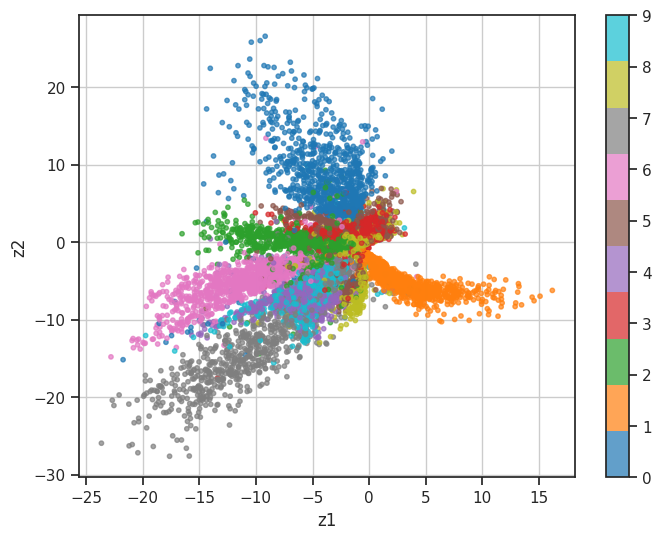

In [14]:
# 잠재벡터 시각화
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid()
plt.show()